<a href="https://colab.research.google.com/github/Abhiram0108/Dataviz-exercises-Abhiram-Thota/blob/main/lecture03_exercise(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('/content/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


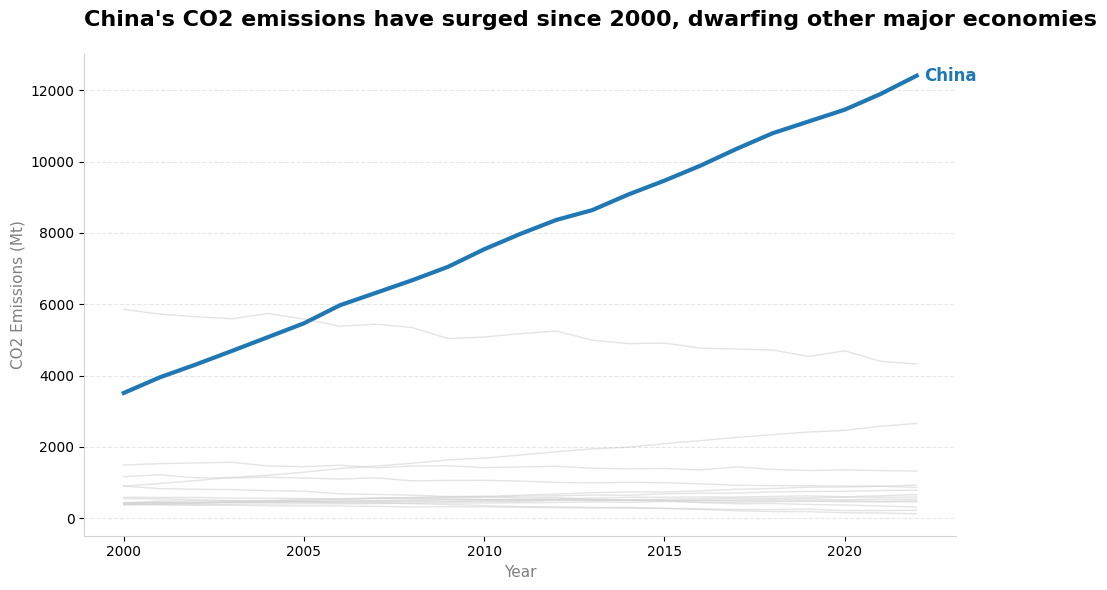

In [6]:
import matplotlib.pyplot as plt

#  Task 1: Multi-series line with highlight (China)
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()

highlight_country = 'China'
countries = df['Country'].unique()

for country in countries:
    data = df[df['Country'] == country]
    if country == highlight_country:
        # Highlight China in professional blue
        plt.plot(data['Year'], data['CO2_Mt'], color='#1f77b4', linewidth=3, zorder=5)
        # Direct Labeling at the end of the line
        last_val = data[data['Year'] == 2022]['CO2_Mt'].values[0]
        plt.text(2022.2, last_val, highlight_country, color='#1f77b4',
                 fontweight='bold', va='center', fontsize=12)
    else:
        # Other countries in light grey "background"
        plt.plot(data['Year'], data['CO2_Mt'], color='lightgrey', linewidth=1, alpha=0.6, zorder=1)

# Formatting Task 1
plt.title("China's CO2 emissions have surged since 2000, dwarfing other major economies",
          fontsize=16, fontweight='bold', pad=20, loc='left')
plt.xlabel("Year", fontsize=11, color='grey')
plt.ylabel("CO2 Emissions (Mt)", fontsize=11, color='grey')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('lightgrey')
ax.spines['bottom'].set_color('lightgrey')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('task1_line_chart.png')


---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


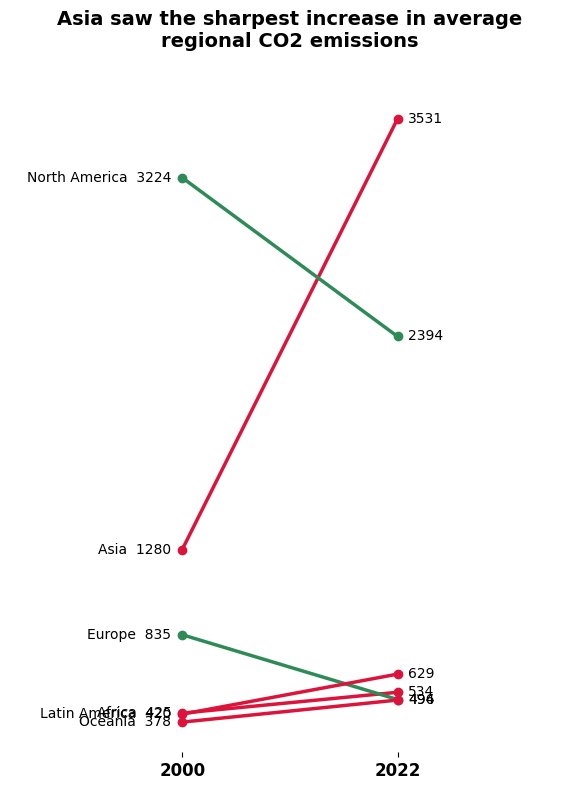

In [7]:
# --- Task 2: Slopegraph: Regional Change 2000 vs 2022 ---
# Aggregate regional averages
regional_df = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()
slope_df = regional_df[regional_df['Year'].isin([2000, 2022])]

plt.figure(figsize=(6, 8), facecolor='white')
ax = plt.gca()

regions = slope_df['Region'].unique()
for region in regions:
    reg_data = slope_df[slope_df['Region'] == region].sort_values('Year')
    y0 = reg_data[reg_data['Year'] == 2000]['CO2_Mt'].values[0]
    y1 = reg_data[reg_data['Year'] == 2022]['CO2_Mt'].values[0]

    # Color logic: Crimson for increase, Green for decrease
    color = 'crimson' if y1 > y0 else 'seagreen'

    # Draw the slope line
    plt.plot([0, 1], [y0, y1], marker='o', color=color, linewidth=2.5)

    # Label region and start value (left side)
    plt.text(-0.05, y0, f"{region}  {y0:.0f}", ha='right', va='center', fontsize=10)
    # Label end value (right side)
    plt.text(1.05, y1, f"{y1:.0f}", ha='left', va='center', fontsize=10)

# Formatting Task 2
plt.title("Asia saw the sharpest increase in average\nregional CO2 emissions",
          fontsize=14, fontweight='bold', pad=30, loc='center')
plt.xlim(-0.8, 1.8) # Provide extra space for labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['2000', '2022'], fontsize=12, fontweight='bold')
ax.set_yticks([]) # Remove y-axis as per requirements
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('task2_slopegraph.png')
